## Assignment 10: Xarray and Cartopy

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import pooch

plt.rcParams['figure.figsize'] = (12, 6)

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fname = pooch.retrieve(
    url="http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc",
    known_hash=None,
    downloader=pooch.HTTPDownloader(verify=False)
)

print(fname)

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
SHA256 hash of downloaded file: a876cc7106e7dcb1344fbec5dcd7510e5cd947e62049a8cbc188ad05ffe00345
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


/home/fc2831/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


In [3]:
ds = xr.open_dataset(fname)
ds

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed


<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [4]:
for var in ds.data_vars:
    long_name = ds[var].attrs.get("long_name", "No long_name available")
    print(f"{var:25s} : {long_name}")

toa_sw_all_mon            : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon            : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon           : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon            : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon            : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon           : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon            : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon            : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon           : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                 : Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon : Cloud Area 

In [5]:
ds_mean = ds.mean(dim="time")
ds_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

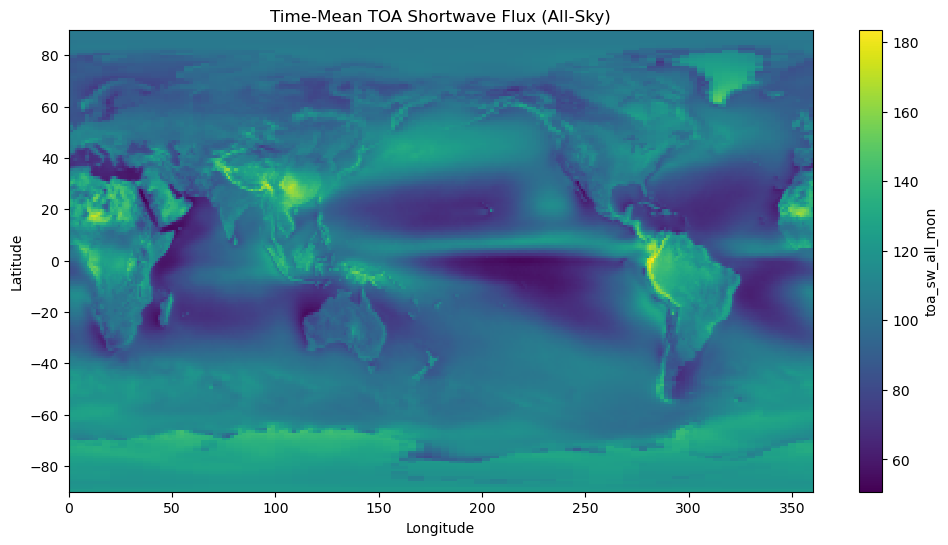

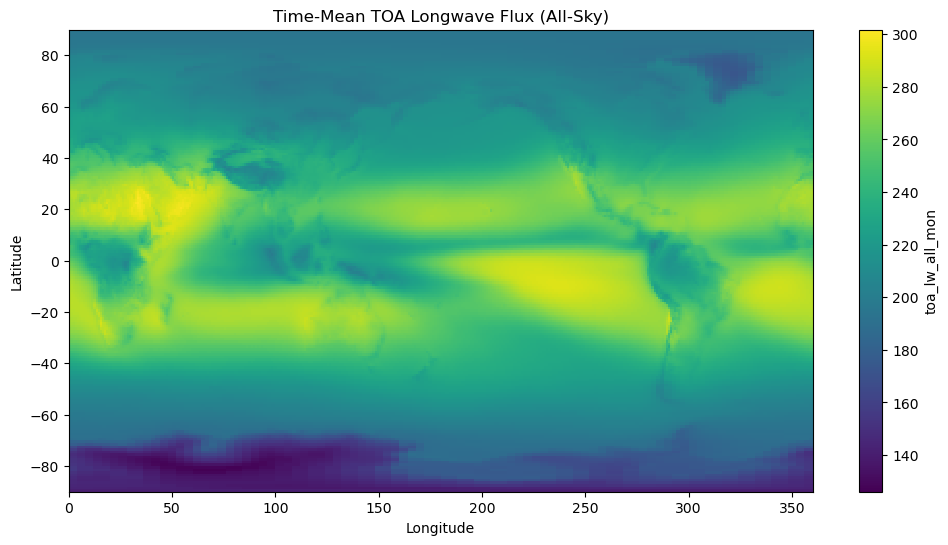

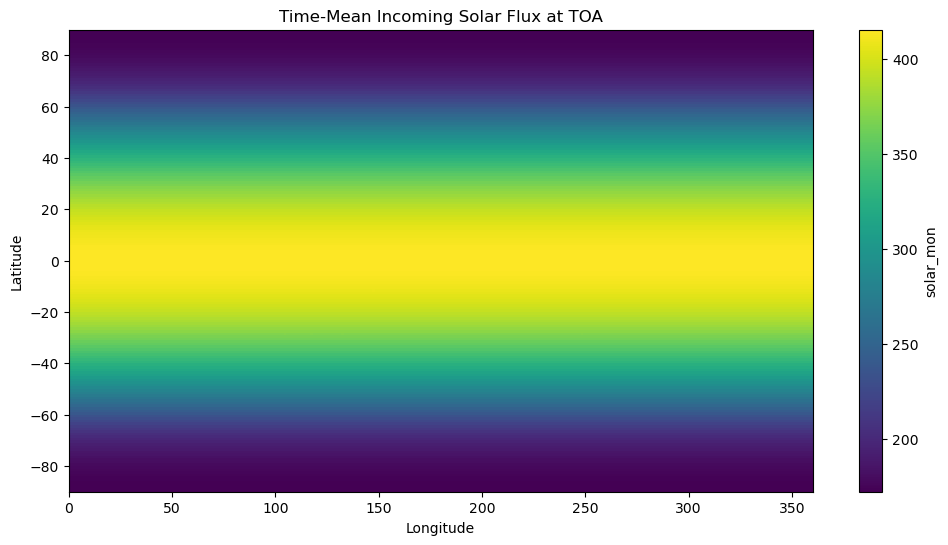

In [9]:
ds_mean["toa_sw_all_mon"].plot(x="lon", y="lat", cmap="viridis")
plt.title("Time-Mean TOA Shortwave Flux (All-Sky)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

ds_mean["toa_lw_all_mon"].plot(x="lon", y="lat", cmap="viridis")
plt.title("Time-Mean TOA Longwave Flux (All-Sky)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

ds_mean["solar_mon"].plot(x="lon", y="lat", cmap="viridis")
plt.title("Time-Mean Incoming Solar Flux at TOA")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [10]:
toa_net_calc = ds_mean["solar_mon"] - ds_mean["toa_sw_all_mon"] - ds_mean["toa_lw_all_mon"]
toa_net_calc

<xarray.DataArray (lat: 180, lon: 360)> Size: 259kB
array([[ -91.28788 ,  -91.28788 ,  -91.28788 , ...,  -91.28788 ,
         -91.28788 ,  -91.28788 ],
       [ -91.457016,  -91.457016,  -91.457016, ...,  -91.457016,
         -91.457016,  -91.457016],
       [ -91.82569 ,  -91.82569 ,  -91.82569 , ...,  -91.82569 ,
         -91.82569 ,  -91.82569 ],
       ...,
       [-125.81961 , -125.81961 , -125.81961 , ..., -125.81961 ,
        -125.81961 , -125.81961 ],
       [-125.93743 , -125.93743 , -125.93743 , ..., -125.93743 ,
        -125.93743 , -125.93743 ],
       [-126.26445 , -126.26445 , -126.26445 , ..., -126.26445 ,
        -126.26445 , -126.26445 ]], dtype=float32)
Coordinates:
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

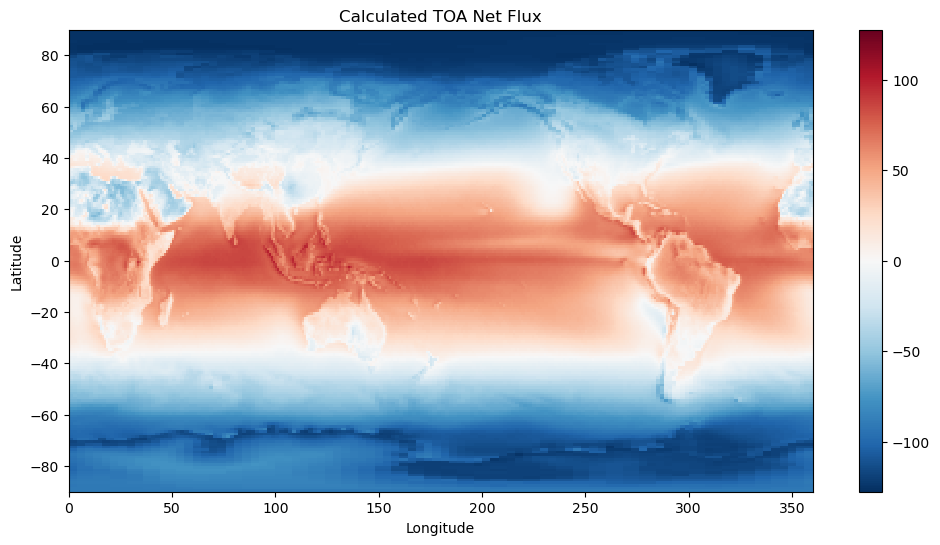

In [11]:
toa_net_calc.plot(x="lon", y="lat", cmap="RdBu_r")
plt.title("Calculated TOA Net Flux")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

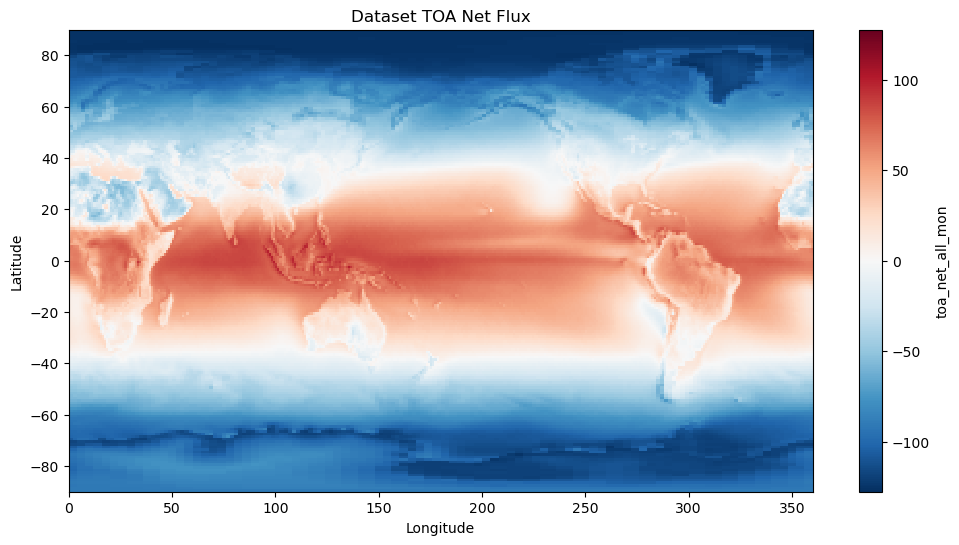

In [12]:
ds_mean["toa_net_all_mon"].plot(x="lon", y="lat", cmap="RdBu_r")
plt.title("Dataset TOA Net Flux")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

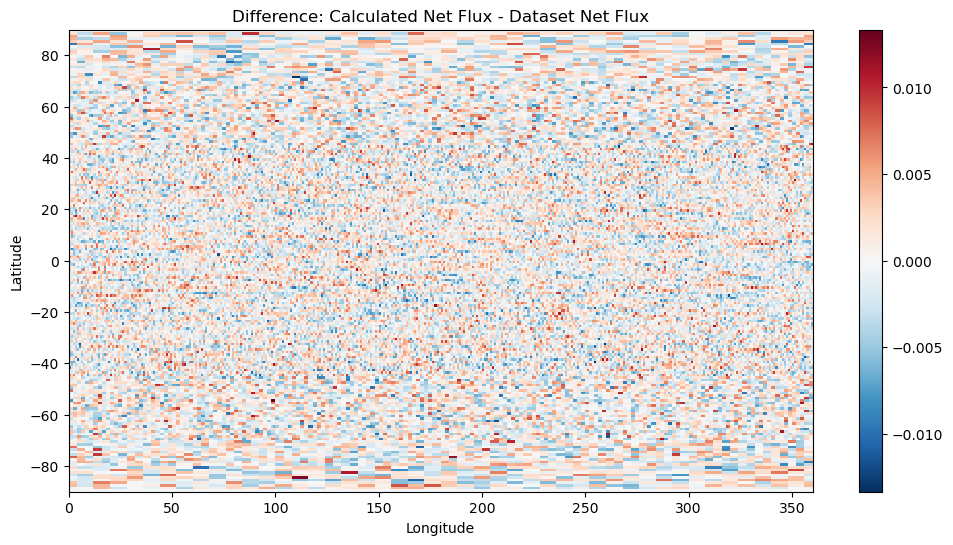

In [14]:
difference = toa_net_calc - ds_mean["toa_net_all_mon"]

difference.plot(x="lon", y="lat", cmap="RdBu_r")
plt.title("Difference: Calculated Net Flux - Dataset Net Flux")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [15]:
print("Minimum difference:", float(difference.min()))
print("Maximum difference:", float(difference.max()))
print("Mean difference:", float(difference.mean()))

Minimum difference: -0.013232707977294922
Maximum difference: 0.013332366943359375
Mean difference: 2.1954205294605345e-05


In [16]:
unweighted_mean = ds_mean["toa_net_all_mon"].mean(dim=("lat", "lon"))
print("Unweighted global mean TOA net radiation:", float(unweighted_mean))

Unweighted global mean TOA net radiation: -28.72901153564453


In [17]:
weights = np.cos(np.deg2rad(ds_mean["lat"]))
weights

<xarray.DataArray 'lat' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.87881714, 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.83388585, 0.8241262 ,
       0.8141155 , 0.8038569 , 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262007, 0.64944804,
       0.6360782 , 0.62251467, 0.6087614 , 0.59482276, 0.58070296,
       0.56640625, 0.551937  , 0.5372996 , 0.5224986 , 0.5075384 ,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051115,
       0.4146933 , 0.3987491 , 0.38268346, 0.3665012 , 0.35020736,
       0.33380693, 0.3173047 , 0.30070582, 0.28401536, 0.26723838,
       0.25037998, 0.23344542, 0.21643965, 0.19936794, 0.18223551,
       0.16504757, 0.14780948, 0.13052624, 0.11320324, 0.09584576,
       0.07845908, 0.06104851, 0.04361945, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]

In [18]:
weighted_mean = ds_mean["toa_net_all_mon"].weighted(weights).mean(dim=("lat", "lon"))
print("Weighted global mean TOA net radiation:", float(weighted_mean))

Weighted global mean TOA net radiation: 0.8780867457389832


In [19]:
solar_global = ds_mean["solar_mon"].weighted(weights).mean(dim=("lat", "lon"))
sw_global = ds_mean["toa_sw_all_mon"].weighted(weights).mean(dim=("lat", "lon"))
lw_global = ds_mean["toa_lw_all_mon"].weighted(weights).mean(dim=("lat", "lon"))

print("Weighted global incoming solar:", float(solar_global))
print("Weighted global outgoing shortwave:", float(sw_global))
print("Weighted global outgoing longwave:", float(lw_global))
print("Solar - SW - LW:", float(solar_global - sw_global - lw_global))

Weighted global incoming solar: 340.2835388183594
Weighted global outgoing shortwave: 99.13859558105469
Weighted global outgoing longwave: 240.26669311523438
Solar - SW - LW: 0.8782501220703125


In [20]:
R = 6_371_000  # Earth radius in meters

lat_rad = np.deg2rad(ds_mean["lat"])
lon_rad = np.deg2rad(ds_mean["lon"])

dlat = np.abs(lat_rad[1] - lat_rad[0])
dlon = np.abs(lon_rad[1] - lon_rad[0])

print("dlat (radians):", float(dlat))
print("dlon (radians):", float(dlon))

dlat (radians): 0.017453312873840332
dlon (radians): 0.01745329424738884


In [21]:
area_1d = (R**2) * np.cos(lat_rad) * dlat * dlon
area_2d = xr.ones_like(ds_mean["toa_net_all_mon"]) * area_1d

area_2d

<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[1.07898062e+08, 1.07898062e+08, 1.07898062e+08, ...,
        1.07898062e+08, 1.07898062e+08, 1.07898062e+08],
       [3.23660931e+08, 3.23660931e+08, 3.23660931e+08, ...,
        3.23660931e+08, 3.23660931e+08, 3.23660931e+08],
       [5.39325207e+08, 5.39325207e+08, 5.39325207e+08, ...,
        5.39325207e+08, 5.39325207e+08, 5.39325207e+08],
       ...,
       [5.39325207e+08, 5.39325207e+08, 5.39325207e+08, ...,
        5.39325207e+08, 5.39325207e+08, 5.39325207e+08],
       [3.23660931e+08, 3.23660931e+08, 3.23660931e+08, ...,
        3.23660931e+08, 3.23660931e+08, 3.23660931e+08],
       [1.07898062e+08, 1.07898062e+08, 1.07898062e+08, ...,
        1.07898062e+08, 1.07898062e+08, 1.07898062e+08]])
Coordinates:
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

In [22]:
area_sum = area_2d.sum(dim=("lat", "lon"))
earth_area_true = 4 * np.pi * R**2

print("Sum of pixel areas:", float(area_sum))
print("Earth surface area (4πR²):", earth_area_true)
print("Difference:", float(area_sum - earth_area_true))

Sum of pixel areas: 510071594879932.1
Earth surface area (4πR²): 510064471909788.25
Difference: 7122970143.875


In [23]:
net_radiation_watts = ds_mean["toa_net_all_mon"] * area_2d
net_radiation_by_lat = net_radiation_watts.sum(dim="lon")

net_radiation_by_lat

<xarray.DataArray (lat: 180)> Size: 1kB
array([-3.54591325e+12, -1.06014933e+13, -1.80171060e+13, -2.57573596e+13,
       -3.40754086e+13, -4.28641871e+13, -5.13863314e+13, -5.96591538e+13,
       -6.78449087e+13, -7.54498904e+13, -8.31854766e+13, -9.05220420e+13,
       -9.70056931e+13, -1.04934412e+14, -1.14619954e+14, -1.23338441e+14,
       -1.31964221e+14, -1.42516359e+14, -1.53246497e+14, -1.62030754e+14,
       -1.69189287e+14, -1.76487906e+14, -1.82780706e+14, -1.84845079e+14,
       -1.84175507e+14, -1.82979655e+14, -1.79744386e+14, -1.77398518e+14,
       -1.75145247e+14, -1.72413686e+14, -1.66473961e+14, -1.62332646e+14,
       -1.58036325e+14, -1.53721804e+14, -1.49651517e+14, -1.45160682e+14,
       -1.39039497e+14, -1.33985371e+14, -1.28509412e+14, -1.22199205e+14,
       -1.16206183e+14, -1.09613853e+14, -1.01964911e+14, -9.37616253e+13,
       -8.49668721e+13, -7.64735383e+13, -6.70240036e+13, -5.72006083e+13,
       -4.71601417e+13, -3.68999374e+13, -2.67240944e+13, -1.71012487e+13,
       -6.17565049e+12,  5.96530140e+12,  1.68845242e+13,  2.63154134e+13,
        3.51120235e+13,  4.49692811e+13,  5.22452588e+13,  6.03061646e+13,
        6.85862231e+13,  7.59661374e+13,  8.36733134e+13,  9.19150307e+13,
        9.97608015e+13,  1.05552025e+14,  1.12840272e+14,  1.19949413e+14,
        1.27713214e+14,  1.36137228e+14,  1.46905405e+14,  1.56408413e+14,
        1.65012700e+14,  1.75317860e+14,  1.87107108e+14,  1.98256646e+14,
        2.09197047e+14,  2.19159307e+14,  2.30510585e+14,  2.40931523e+14,
...
        2.75245565e+14,  2.70279081e+14,  2.56123776e+14,  2.37233041e+14,
        2.16284570e+14,  1.93761217e+14,  1.74417975e+14,  1.54375045e+14,
        1.35124297e+14,  1.22776667e+14,  1.12935110e+14,  1.02644490e+14,
        9.28940889e+13,  8.42324122e+13,  7.53603743e+13,  6.44834743e+13,
        5.57949535e+13,  4.22198181e+13,  3.56620710e+13,  2.93768354e+13,
        2.19259184e+13,  2.33764837e+13,  2.18754109e+13,  1.93237656e+13,
        1.26202137e+13,  4.92340685e+12, -2.31638413e+12, -1.20533677e+13,
       -2.26329988e+13, -3.43087480e+13, -4.42936547e+13, -5.29804257e+13,
       -6.20348394e+13, -7.26830430e+13, -8.18681342e+13, -9.03123011e+13,
       -9.84624830e+13, -1.06768194e+14, -1.14103738e+14, -1.19534511e+14,
       -1.25045627e+14, -1.30818145e+14, -1.35595499e+14, -1.39364364e+14,
       -1.42507665e+14, -1.46298908e+14, -1.50736249e+14, -1.52816306e+14,
       -1.53193406e+14, -1.54113628e+14, -1.58312741e+14, -1.59915796e+14,
       -1.59964531e+14, -1.59674850e+14, -1.59834157e+14, -1.60285761e+14,
       -1.58478626e+14, -1.57355569e+14, -1.56079372e+14, -1.54075218e+14,
       -1.51029314e+14, -1.48480863e+14, -1.45203253e+14, -1.40208543e+14,
       -1.34208482e+14, -1.27355199e+14, -1.20557672e+14, -1.13381534e+14,
       -1.05991382e+14, -9.75692533e+13, -8.90333967e+13, -7.99775869e+13,
       -7.14595747e+13, -6.28548033e+13, -5.34982416e+13, -4.38575095e+13,
       -3.41336795e+13, -2.44312946e+13, -1.46783812e+13, -4.90453622e+12])
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5

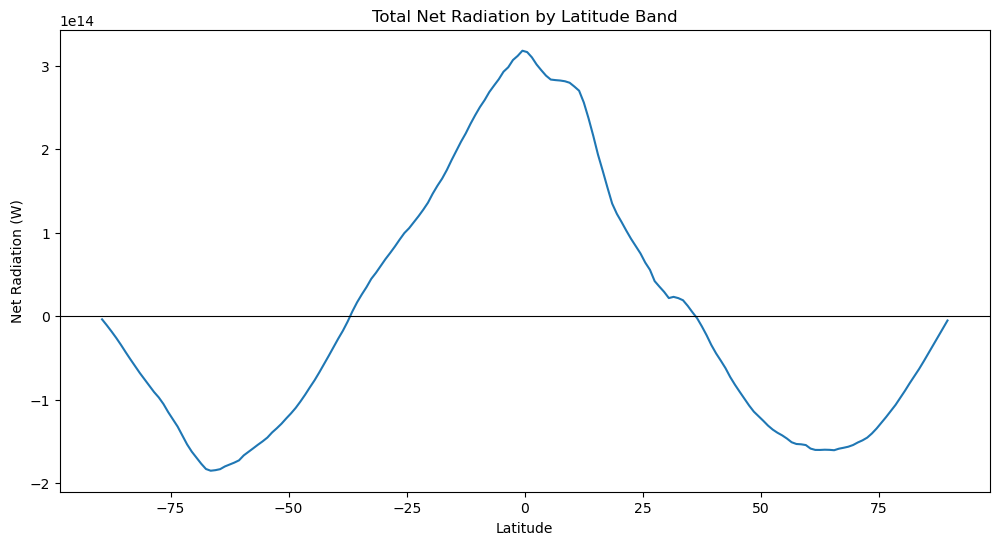

In [24]:
net_radiation_by_lat.plot()
plt.title("Total Net Radiation by Latitude Band")
plt.xlabel("Latitude")
plt.ylabel("Net Radiation (W)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

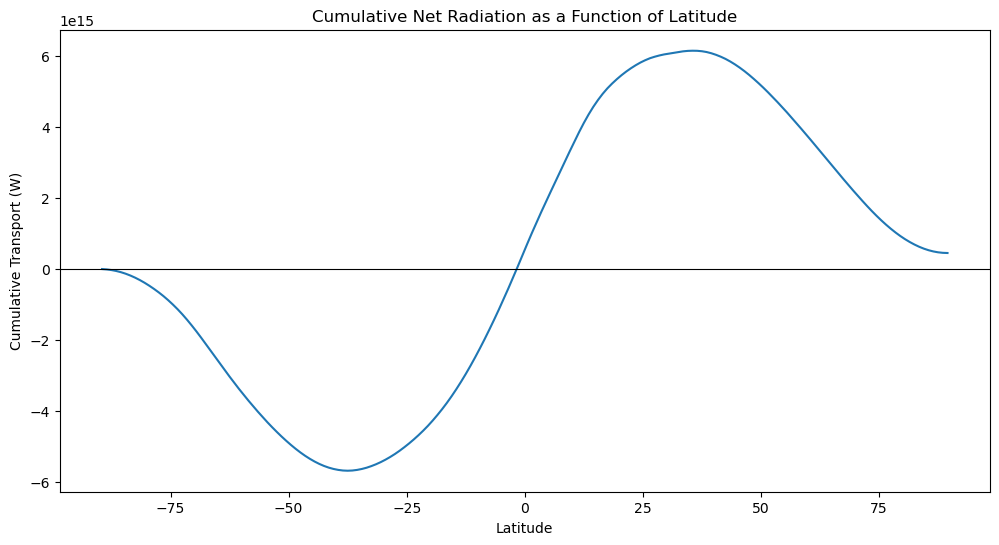

In [25]:
cumulative_transport = net_radiation_by_lat.cumsum(dim="lat")

cumulative_transport.plot()
plt.title("Cumulative Net Radiation as a Function of Latitude")
plt.xlabel("Latitude")
plt.ylabel("Cumulative Transport (W)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [27]:
url_hgt = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/pressure/hgt.201810.nc"
url_precip = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/monolevel/apcp.2018.nc"

ds_hgt = xr.open_dataset(url_hgt, engine="netcdf4")
ds_precip = xr.open_dataset(url_precip, engine="netcdf4")

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'apcp' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [28]:
ds_hgt

<xarray.Dataset> Size: 348MB
Dimensions:            (time: 31, level: 29, y: 277, x: 349, nbnds: 2)
Coordinates:
  * time               (time) datetime64[ns] 248B 2018-10-01 ... 2018-10-31
  * level              (level) float32 116B 1e+03 975.0 950.0 ... 125.0 100.0
  * y                  (y) float32 1kB 0.0 3.246e+04 ... 8.927e+06 8.96e+06
  * x                  (x) float32 1kB 0.0 3.246e+04 ... 1.126e+07 1.13e+07
    lat                (y, x) float32 387kB ...
    lon                (y, x) float32 387kB ...
Dimensions without coordinates: nbnds
Data variables:
    Lambert_Conformal  int32 4B ...
    time_bnds          (time, nbnds) float64 496B ...
    hgt                (time, level, y, x) float32 348MB ...
Attributes: (12/17)
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.2
    centerlat:                       50.0
    centerlon:                       -107.0
    comments:                        
    institution:                     National Centers for Environmental Predi...
    ...                              ...
    title:                           Daily NARR
    history:                         created Sat Mar 26 07:07:59 MDT 2016 by ...
    dataset_title:                   NCEP North American Regional Reanalysis ...
    references:                      https://www.esrl.noaa.gov/psd/data/gridd...
    source:                          http://www.emc.ncep.noaa.gov/mmb/rreanl/...
    DODS_EXTRA.Unlimited_Dimension:  time

In [29]:
ds_precip

<xarray.Dataset> Size: 142MB
Dimensions:            (time: 365, y: 277, x: 349, nbnds: 2)
Coordinates:
  * time               (time) datetime64[ns] 3kB 2018-01-01 ... 2018-12-31
  * y                  (y) float32 1kB 0.0 3.246e+04 ... 8.927e+06 8.96e+06
  * x                  (x) float32 1kB 0.0 3.246e+04 ... 1.126e+07 1.13e+07
    lat                (y, x) float32 387kB ...
    lon                (y, x) float32 387kB ...
Dimensions without coordinates: nbnds
Data variables:
    Lambert_Conformal  int32 4B ...
    time_bnds          (time, nbnds) float64 6kB ...
    apcp               (time, y, x) float32 141MB ...
Attributes: (12/17)
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.2
    centerlat:                       50.0
    centerlon:                       -107.0
    comments:                        
    institution:                     National Centers for Environmental Predi...
    ...                              ...
    title:                           Daily NARR
    history:                         created Sat Mar 26 04:56:06 MDT 2016 by ...
    dataset_title:                   NCEP North American Regional Reanalysis ...
    references:                      https://www.esrl.noaa.gov/psd/data/gridd...
    source:                          http://www.emc.ncep.noaa.gov/mmb/rreanl/...
    DODS_EXTRA.Unlimited_Dimension:  time

In [30]:
hgt_500 = ds_hgt["hgt"].sel(time="2018-10-15", level=500)
precip_day = ds_precip["apcp"].sel(time="2018-10-15")

hgt_500

<xarray.DataArray 'hgt' (y: 277, x: 349)> Size: 387kB
[96673 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2018-10-15
    level    float32 4B 500.0
  * y        (y) float32 1kB 0.0 3.246e+04 6.493e+04 ... 8.927e+06 8.96e+06
  * x        (x) float32 1kB 0.0 3.246e+04 6.493e+04 ... 1.126e+07 1.13e+07
    lat      (y, x) float32 387kB ...
    lon      (y, x) float32 387kB ...
Attributes: (12/14)
    GRIB_id:        7
    GRIB_name:      HGT
    grid_mapping:   Lambert_Conformal
    level_desc:     Pressure Levels
    standard_name:  geopotential_height
    units:          m
    ...             ...
    dataset:        NARR Daily Averages
    long_name:      Daily Geopotential Heights on Pressure Levels
    parent_stat:    Individual Obs
    statistic:      Mean
    actual_range:   [ -341.88077 16761.062  ]
    _ChunkSizes:    [  1   1 277 349]

In [31]:
precip_day

<xarray.DataArray 'apcp' (y: 277, x: 349)> Size: 387kB
[96673 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2018-10-15
  * y        (y) float32 1kB 0.0 3.246e+04 6.493e+04 ... 8.927e+06 8.96e+06
  * x        (x) float32 1kB 0.0 3.246e+04 6.493e+04 ... 1.126e+07 1.13e+07
    lat      (y, x) float32 387kB ...
    lon      (y, x) float32 387kB ...
Attributes: (12/14)
    GRIB_id:        61
    GRIB_name:      APCP
    grid_mapping:   Lambert_Conformal
    level_desc:     Surface
    standard_name:  precipitation_amount
    units:          kg/m^2
    ...             ...
    long_name:      Daily accumulated total precipitation at Surface
    parent_stat:    Individual Obs
    statistic:      Sum
    valid_range:    [  0. 800.]
    actual_range:   [  0.   332.75]
    _ChunkSizes:    [  1 277 349]

In [32]:
ds_hgt["Lambert_Conformal"]

<xarray.DataArray 'Lambert_Conformal' ()> Size: 4B
[1 values with dtype=int32]
Attributes:
    false_easting:                  5632642.22547
    false_northing:                 4612545.65137
    grid_mapping_name:              lambert_conformal_conic
    latitude_of_projection_origin:  50.0
    longitude_of_central_meridian:  -107.0
    standard_parallel:              [50. 50.]

In [33]:
print("hgt_500 min:", float(hgt_500.min()))
print("hgt_500 max:", float(hgt_500.max()))

print("precip_day min:", float(precip_day.min()))
print("precip_day max:", float(precip_day.max()))

hgt_500 min: 5007.12646484375
hgt_500 max: 5949.93896484375
precip_day min: 0.0
precip_day max: 225.9296875


In [36]:
proj = ccrs.LambertConformal(
    central_longitude=-107.0,
    central_latitude=50.0,
    standard_parallels=(50.0, 50.0),
    false_easting=5632642.22547,
    false_northing=4612545.65137
)

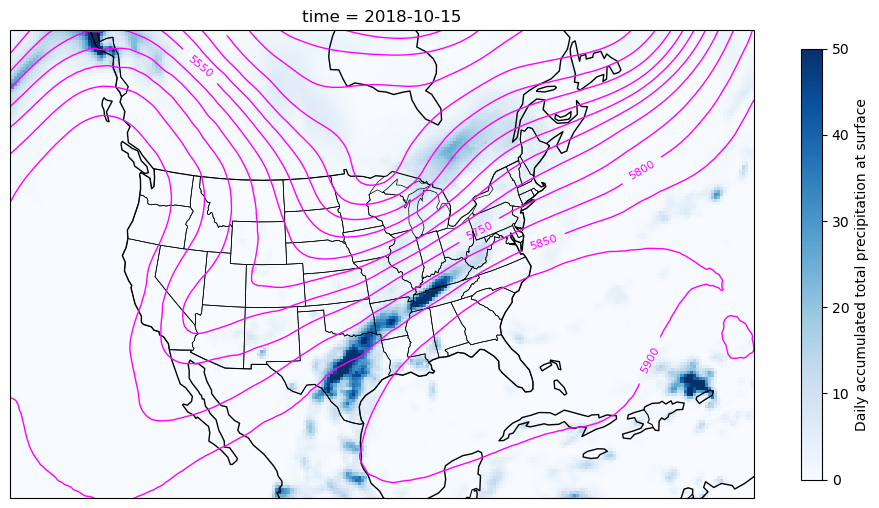

In [38]:
proj = ccrs.LambertConformal(
    central_longitude=-107.0,
    central_latitude=50.0,
    standard_parallels=(50.0, 50.0),
    false_easting=5632642.22547,
    false_northing=4612545.65137
)

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=proj)

precip_plot = ax.pcolormesh(
    ds_precip["x"],
    ds_precip["y"],
    precip_day,
    transform=proj,
    cmap="Blues",
    vmin=0,
    vmax=50
)

contours = ax.contour(
    ds_hgt["x"],
    ds_hgt["y"],
    hgt_500,
    levels=np.arange(5100, 6001, 50),
    colors="magenta",
    linewidths=1,
    transform=proj
)

ax.clabel(contours, inline=True, fontsize=8, fmt="%d")

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.5)

ax.set_extent([-130, -60, 20, 55], crs=ccrs.PlateCarree())

ax.set_title("time = 2018-10-15")

cbar = plt.colorbar(precip_plot, ax=ax, shrink=0.7)
cbar.set_label("Daily accumulated total precipitation at surface")

plt.show()

In [39]:
url_ice = "https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc"

fname_ice = pooch.retrieve(
    url=url_ice,
    known_hash=None
)

ds_ice = xr.open_dataset(fname_ice, drop_variables="melt_onset_day_seaice_conc_cdr")
ds_ice

SHA256 hash of downloaded file: 19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:                             Comiso, J. C., and F. Nishio. 200...
    program:                                NOAA Climate Data Record Program
    cdr_variable:                           seaice_conc_cdr
    software_version_id:                    git@bitbucket.org:nsidc/seaice_cd...
    Metadata_Link:                          https://nsidc.org/api/dataset/met...
    product_version:                        v03r01
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    proj_units:                             meters

In [40]:
for var in ds_ice.data_vars:
    print(var)

projection
seaice_conc_cdr
stdev_of_seaice_conc_cdr
qa_of_seaice_conc_cdr
goddard_merged_seaice_conc
goddard_nt_seaice_conc
goddard_bt_seaice_conc


In [41]:
ds_ice

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:                             Comiso, J. C., and F. Nishio. 200...
    program:                                NOAA Climate Data Record Program
    cdr_variable:                           seaice_conc_cdr
    software_version_id:                    git@bitbucket.org:nsidc/seaice_cd...
    Metadata_Link:                          https://nsidc.org/api/dataset/met...
    product_version:                        v03r01
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    proj_units:                             meters

In [42]:
list(ds_ice.variables)

['projection',
 'seaice_conc_cdr',
 'stdev_of_seaice_conc_cdr',
 'qa_of_seaice_conc_cdr',
 'goddard_merged_seaice_conc',
 'goddard_nt_seaice_conc',
 'goddard_bt_seaice_conc',
 'time',
 'ygrid',
 'xgrid',
 'latitude',
 'longitude']

In [43]:
ds_ice["projection"]

<xarray.DataArray 'projection' ()> Size: 1B
[1 values with dtype=|S1]
Attributes: (12/23)
    grid_boundary_top_projected_y:          4350000.0
    grid_boundary_bottom_projected_y:       -3950000.0
    grid_boundary_right_projected_x:        3950000.0
    grid_boundary_left_projected_x:         -3950000.0
    parent_grid_cell_row_subset_start:      0.0
    parent_grid_cell_row_subset_end:        332.0
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    units:                                  meters

In [44]:
ice = ds_ice["seaice_conc_cdr"].sel(time="2017-08-07")
print("ice min:", float(ice.min()))
print("ice max:", float(ice.max()))
ice

ice min: 0.0
ice max: 2.5399999618530273


<xarray.DataArray 'seaice_conc_cdr' (time: 1, ygrid: 332, xgrid: 316)> Size: 420kB
array([[[0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.],
        ...,
        [0., 0., ..., 0., 0.],
        [0., 0., ..., 0., 0.]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid      (ygrid) float32 1kB 4.338e+06 4.312e+06 ... -3.912e+06 -3.938e+06
  * xgrid      (xgrid) float32 1kB -3.938e+06 -3.912e+06 ... 3.912e+06 3.938e+06
    latitude   (ygrid, xgrid) float64 839kB ...
    longitude  (ygrid, xgrid) float64 839kB ...
Attributes: (12/13)
    valid_range:            [  0 100]
    long_name:              NOAA/NSIDC Climate Data Record of Passive Microwa...
    standard_name:          sea_ice_area_fraction
    units:                  1
    flag_values:            [-5 -4 -3 -2 -1]
    flag_meanings:          pole_hole lakes coastal land_mask missing_data
    ...                     ...
    grid_mapping:           projection
    reference:              https://nsidc.org/api/dataset/metadata/v2/oai?ver...
    ancillary_variables:    stdev_of_seaice_conc_cdr qa_of_seaice_conc_cdr
    cell_methods:           time: mean (interval: 1 day)
    coverage_content_type:  physicalMeasurement
    ioos_category:          Ice Distribution

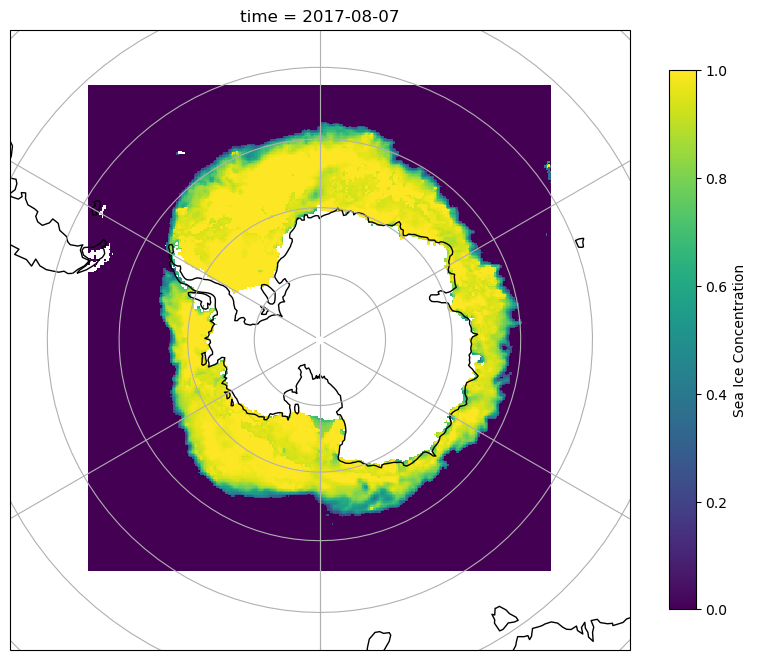

In [45]:
ice = ds_ice["seaice_conc_cdr"].sel(time="2017-08-07").squeeze()

# Mask invalid values above 1
ice = ice.where(ice <= 1)

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

ice_plot = ax.pcolormesh(
    ds_ice["xgrid"],
    ds_ice["ygrid"],
    ice,
    transform=ccrs.SouthPolarStereo(),
    cmap="viridis",
    vmin=0,
    vmax=1
)

ax.coastlines()
ax.gridlines()

ax.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
ax.set_title("time = 2017-08-07")

cbar = plt.colorbar(ice_plot, ax=ax, shrink=0.7)
cbar.set_label("Sea Ice Concentration")

plt.show()

In [46]:
import pandas as pd

url_eq = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"
eq = pd.read_csv(url_eq)

eq.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [47]:
eq.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type'],
      dtype='object')

In [48]:
top50 = eq.nlargest(50, "mag")
top50[["time", "latitude", "longitude", "mag"]].head()

,time,latitude,longitude,mag
37371,2014-04-01 23:46:47.260,-19.6097,-70.7691,8.2
50562,2014-06-23 20:53:09.700,51.8486,178.7352,7.9
36918,2014-04-03 02:43:13.110,-20.5709,-70.4931,7.7
33808,2014-04-12 20:14:39.300,-11.2701,162.1481,7.6
31496,2014-04-19 13:28:00.810,-6.7547,155.0241,7.5


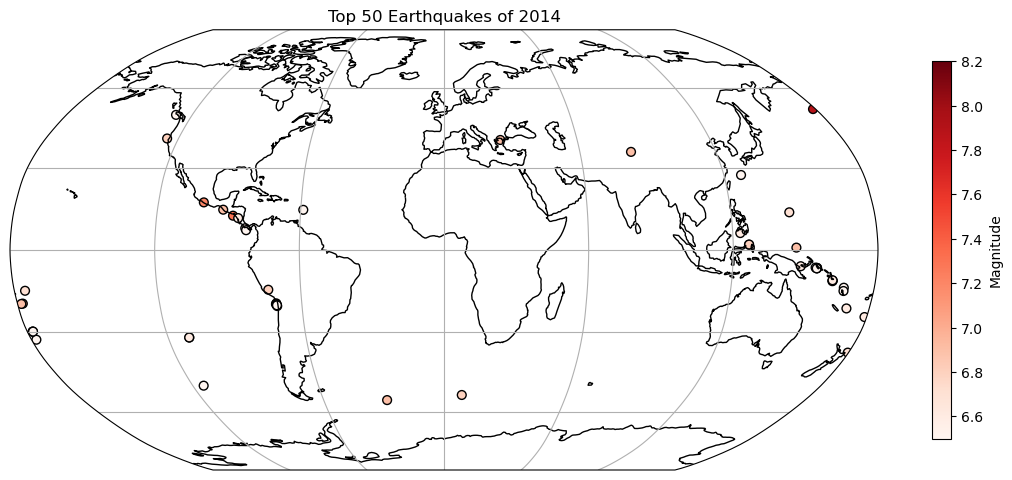

In [49]:
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.Robinson())

ax.set_global()
ax.coastlines()
ax.gridlines()

scatter = ax.scatter(
    top50["longitude"],
    top50["latitude"],
    c=top50["mag"],
    s=40,
    cmap="Reds",
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax.set_title("Top 50 Earthquakes of 2014")

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Magnitude")

plt.show()